# Basics of Information Retrieval

In [14]:
from porter import stem
import matplotlib.pyplot as plt
import numpy as np

# Exo 1

In [ ]:
docs = ["the new home has been saled on top forecasts",
         "the home sales rise in july",
         "there is an increase in home sales in july",
         "july encounter a new home sales rise"
         ]
stop_words = ["the", "a", "an", "on", "behind", "under", "there", "in", "on"]

## Q1.1

In [73]:
def get_terms(text, stop_words=stop_words):
    terms = []
    for token in text.split():
        term = stem(token.lower())
        if term not in stop_words:
            terms.append(term)
    return terms
    
def count_terms(doc):
    tf = {}
    for term in get_terms(doc):
        if term not in tf:
            tf[term] = 0
        tf[term] += 1
    return tf
    

In [74]:
count_terms(docs[0])

{'new': 1, 'home': 1, 'ha': 1, 'been': 1, 'sale': 1, 'top': 1, 'forecast': 1}

## Q1.2-Q1.3

In [89]:
def get_index(docs):
    index = {}
    for i, doc in enumerate(docs):
        index[i] = count_terms(doc)
    return index

# def get_inverted_index(docs,weighting="tf"):
#     inverted_index = {}
#     for i, doc in enumerate(docs):
#         for term, tf in count_terms(doc).items():
#             if term not in inverted_index:
#                 inverted_index[term] = {}
#             inverted_index[term][i] = tf
            
#     return inverted_index

def get_inverted_index(docs,weighting="tf"):
    assert weighting in ["tf", "tfidf"]
    inverted_index = {}
    n_docs = len(docs)
    df = {}
    for i, doc in enumerate(docs):
        for term, tf in count_terms(doc).items():
            if term not in inverted_index:
                inverted_index[term] = {}
            if term not in df:
                df[term] = 0
            inverted_index[term][i] = tf
            df[term] += 1
            
    if weighting == "tfidf":
        for term in inverted_index:
            idf = float(np.log((n_docs + 1) / (df[term] + 1))+1)
            for i in inverted_index[term]:
                inverted_index[term][i] *= idf

    return inverted_index
        

In [90]:
get_index(docs)

{0: {'new': 1,
  'home': 1,
  'ha': 1,
  'been': 1,
  'sale': 1,
  'top': 1,
  'forecast': 1},
 1: {'home': 1, 'sale': 1, 'rise': 1, 'juli': 1},
 2: {'is': 1, 'increas': 1, 'home': 1, 'sale': 1, 'juli': 1},
 3: {'juli': 1, 'encount': 1, 'new': 1, 'home': 1, 'sale': 1, 'rise': 1}}

In [91]:
get_inverted_index(docs)

{'new': {0: 1, 3: 1},
 'home': {0: 1, 1: 1, 2: 1, 3: 1},
 'ha': {0: 1},
 'been': {0: 1},
 'sale': {0: 1, 1: 1, 2: 1, 3: 1},
 'top': {0: 1},
 'forecast': {0: 1},
 'rise': {1: 1, 3: 1},
 'juli': {1: 1, 2: 1, 3: 1},
 'is': {2: 1},
 'increas': {2: 1},
 'encount': {3: 1}}

In [93]:
get_inverted_index(docs, weighting="tfidf")

{'new': {0: 1.5108256237659907, 3: 1.5108256237659907},
 'home': {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0},
 'ha': {0: 1.916290731874155},
 'been': {0: 1.916290731874155},
 'sale': {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0},
 'top': {0: 1.916290731874155},
 'forecast': {0: 1.916290731874155},
 'rise': {1: 1.5108256237659907, 3: 1.5108256237659907},
 'juli': {1: 1.2231435513142097, 2: 1.2231435513142097, 3: 1.2231435513142097},
 'is': {2: 1.916290731874155},
 'increas': {2: 1.916290731874155},
 'encount': {3: 1.916290731874155}}

# Exercise 2

Boolean model: query is conjunction of terms

Vector approach: binary, tf, tf-idf vectors or embeddings 

## Q2.1 2.2

In [ ]:
query = "home sales top"

In [101]:
def compute_scores_boolean(query, docs):
    """returns 1 for documents that have all the terms from query, 0 otherwise"""
    index = get_index(docs)
    query_terms = get_terms(query)
    scores = [int(set(index[i_doc].keys()) >= set(query_terms)) for i_doc in range(len(docs))]
    return scores

compute_scores_boolean(query, docs)

[1, 0, 0, 0]

## Q2.3

In [133]:
def compute_scores_vectorial(query, docs):
    """Computes dot product between sparse vector representations"""
    docs_index = get_inverted_index(docs, weighting="tf")
    query_index = get_inverted_index([query], weighting="tf")
    scores = [
        sum(
            [
                docs_index[term].get(i_doc,0) * query_index[term][0]
                for term in query_index.keys()
            ]
        )
        for i_doc in range(len(docs))
    ]
    return scores

compute_scores_vectorial(query, docs)

[3, 2, 2, 2]

In [136]:
def compute_scores_lm(query, docs, llambda=0.5):
    """Query likelihood model with Jelineck-Mercer P(t|d) smoothing"""
    p_jm = np.ones(len(docs))
    query_terms = get_terms(query)
    index = get_index(docs)
    nb_terms = np.sum(
        [count for _, counts in index.items() for count in counts.values()]
    )
    for term in query_terms:
        # frequency of a term in the doc -> model of the doc
        p_term_doc = np.zeros(len(docs))
        # frequency of a term in the corpus -> for smoothing (to avoid zeros)
        p_term_corpus = np.zeros(len(docs))
        corpus_term_count = 0
        for i_doc, doc in enumerate(docs):
            term_count = index[i_doc][term] if term in index[i_doc] else 0
            p_term_doc[i_doc] = term_count / np.sum(
                [count for count in index[i_doc].values()]
            )
            corpus_term_count += term_count
            p_term_corpus[i_doc] = corpus_term_count / nb_terms
        p_jm *= (1 - llambda) * p_term_doc + llambda * p_term_corpus
    return p_jm

compute_scores_lm(query, docs, 0.1)

array([0.00235885, 0.00024908, 0.00017043, 0.00012857])

# Exercise 3

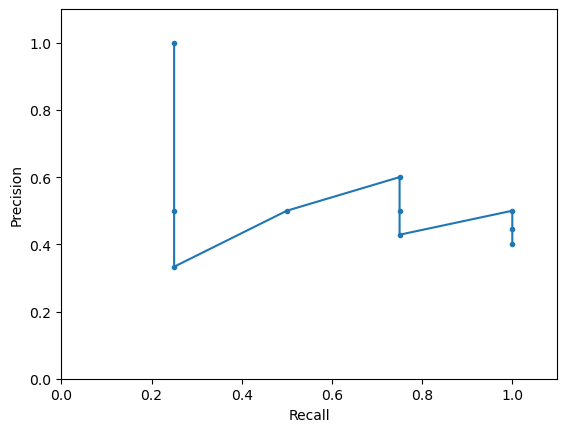

(array([0.25, 0.25, 0.25, 0.5 , 0.75, 0.75, 0.75, 1.  , 1.  , 1.  ]),
 array([1.        , 0.5       , 0.33333333, 0.5       , 0.6       ,
        0.5       , 0.42857143, 0.5       , 0.44444444, 0.4       ]))

In [150]:
def get_pr_curve(retrieved_relevance, plot=True):
    all_t = np.sum(retrieved_relevance)
    precision = np.ones(len(retrieved_relevance))
    recall = np.ones(len(retrieved_relevance))
    if sum(retrieved_relevance)==0:
        return recall, precision
    for i in range(len(retrieved_relevance)):
        retrieved = retrieved_relevance[:i+1]
        tp = np.sum(retrieved)
        fp = i + 1 - tp
        fn = all_t - tp
        precision[i] = tp / (tp + fp)
        recall[i] = tp / (tp + fn)
        
        # if plot: 
        #     plt.text(recall[i], precision[i], s=str(i+1))
    
    if plot:
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.plot(recall, precision, ".-") # , marker="o"
        plt.xlim([0,1.1])
        plt.ylim([0,1.1])
        plt.show()
    return recall, precision
    
get_pr_curve(np.array([1, 0, 0, 1 ,1, 0, 0, 1, 0, 0]))

In [161]:
def get_dcg(retrieved_relevance):
    return sum([rel / np.log2(i+2) for i, rel in enumerate(retrieved_relevance)])
        
def get_ndcg(retrieved_relevance):
    dcg = get_dcg(retrieved_relevance)
    print(dcg)
    # Ideal case (perfect sorting)
    idcg = get_dcg(sorted(retrieved_relevance, reverse=True))
    return dcg / idcg

## Q3.1 - Q3.2

Query: top sales
Ranking: [0 1 2 3]
Relevance of retrieved documents: [1 0 0 0]


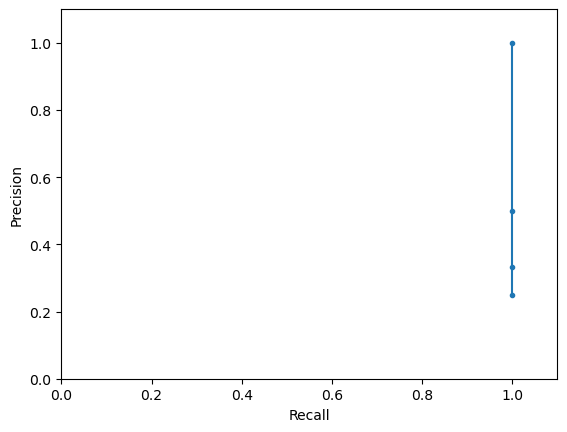

P@2 = 0.5
R@2 = 1.0
F1@2 = 0.6666666666666666
1.0
NDCG = 1.0

Query: sales increase july
Ranking: [2 3 1 0]
Relevance of retrieved documents: [1 0 1 0]


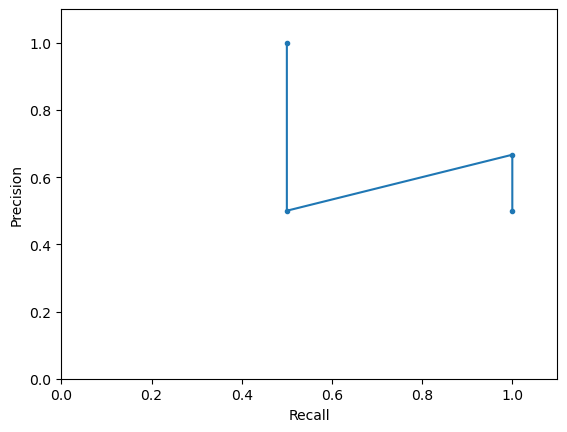

P@2 = 0.5
R@2 = 0.5
F1@2 = 0.5
1.5
NDCG = 0.9197207891481876

Query: new home
Ranking: [3 0 1 2]
Relevance of retrieved documents: [0 0 0 0]
P@2 = 1.0
R@2 = 1.0
F1@2 = 1.0
0.0
NDCG = nan

Average over all queries:
P@2 = 0.6666666666666666
R@2 = 0.8333333333333334
F1@2 = 0.7222222222222222


/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_64452/2201945541.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return dcg / idcg


In [162]:
qrels = {"top sales": [0], "sales increase july": [1, 2], "new home": []}
p_2_avg = 0
r_2_avg = 0
f1_2_avg = 0
for query, relevant_docs in qrels.items():
    print("Query:", query)
    scores = compute_scores_lm(
        query, docs, 0.1
    )  # compute_scores_vectorial(query, docs)
    ranking = scores.argsort()[::-1]
    print("Ranking:", ranking)
    retrieved_relevance = np.array([int(i_doc in relevant_docs) for i_doc in ranking])
    print("Relevance of retrieved documents:", retrieved_relevance)
    recall, precision = get_pr_curve(retrieved_relevance)
    p_2 = precision[1]
    r_2 = recall[1]
    f1_2 = 2 / (1 / recall[1] + 1 / precision[1])
    print("P@2 =", p_2)
    print("R@2 =", r_2)
    print("F1@2 =", f1_2)
    print("NDCG =", get_ndcg(retrieved_relevance))
    print()
    p_2_avg += p_2
    r_2_avg += r_2
    f1_2_avg += f1_2
 
p_2_avg /= len(qrels)
r_2_avg /= len(qrels)
f1_2_avg /= len(qrels) 
print("Average over all queries:")
print("P@2 =", p_2_avg)
print("R@2 =", r_2_avg)
print("F1@2 =", f1_2_avg)